# K-Means Clustering from Scratch

This notebook implements the **K-Means clustering algorithm** from scratch using only NumPy, then compares the result against scikit-learn's optimized implementation.

## How K-Means works
K-Means partitions `n` data points into `k` clusters by alternating between two steps until convergence:

1. **Assignment step (E-step):** assign each point to the nearest centroid, using Euclidean distance:
   $$d(x, c) = \sqrt{\sum_{j=1}^{m} (x_j - c_j)^2}$$
2. **Update step (M-step):** recompute each centroid as the mean of the points assigned to it:
   $$c_i = \frac{1}{|C_i|} \sum_{x \in C_i} x$$

The algorithm stops when centroids no longer change (convergence) or after a fixed number of iterations.

## Dataset
A small toy dataset with 9 customers, each described by two features: `age` and `expenditure`. The goal is to group customers into `k = 3` clusters (e.g. young/high-spending, middle-aged/medium-spending, senior/low-spending).

## 1. Imports and toy dataset

In [1]:
import numpy as np
from matplotlib import pyplot as plt

# Feature 1: customer age
age = np.array([18, 20, 22,
                30, 34, 40,
                60, 66, 70])

# Feature 2: customer expenditure (e.g. monthly spending)
expenditure = np.array([80, 90, 85,
                   50, 64, 60,
                   30, 40, 25])

## 2. Build the feature matrix

Stack `age` and `expenditure` into a single 2D array `X` of shape `(n_samples, n_features)` = `(9, 2)`. Each row is one data point (customer); each column is one feature.

In [2]:
# Combine the two 1D feature arrays into one (9, 2) matrix:
# column 0 = age, column 1 = expenditure
X = np.column_stack((age, expenditure))
X

array([[18, 80],
       [20, 90],
       [22, 85],
       [30, 50],
       [34, 64],
       [40, 60],
       [60, 30],
       [66, 40],
       [70, 25]])

## 3. Initialize hyperparameters and centroids

- `k`: number of clusters to form.
- `max_iters`: maximum number of assignment/update cycles.
- `centroids`: starting centroid positions.

**Note on initialization:** here the initial centroids are simply taken as a slice of the raw data (`X[2:k+2]`), not chosen randomly or via `k-means++`. This is a simplified/naive approach used for learning purposes — in practice, a poor initialization can lead to slow convergence or a bad local optimum (see the scikit-learn comparison below, which uses `k-means++`).

In [3]:
k = 3            # number of clusters
max_iters = 2     # maximum number of iterations

# Naive initialization: just pick 3 existing data points as the starting centroids
# (rows at index 2, 3, 4 of X). This is NOT random or k-means++ initialization.
centroids = X[2:k+2]
print('Init centroids: \n', centroids)

Init centroids: 
 [[22 85]
 [30 50]
 [34 64]]


## 4. Main K-Means loop

Repeat until convergence or `max_iters` is reached:

1. Compute the Euclidean distance from every point to every centroid.
2. Assign each point to its closest centroid (`labels`).
3. Recompute each centroid as the mean of the points currently assigned to it.
4. Stop early if centroids stop changing.

In [4]:
for _ in range(max_iters):
  # --- Assignment step ---
  # X[:, np.newaxis, :] reshapes X from (n, 2) to (n, 1, 2) so it can be
  # broadcast against centroids of shape (k, 2), producing an (n, k, 2) array
  # of per-coordinate differences. Squaring, summing over the last axis, and
  # taking the square root gives the (n, k) matrix of Euclidean distances
  # from every point to every centroid.
  distance = np.sqrt(np.sum((X[:,np.newaxis,:] - centroids)**2, axis = 2))

  # For each point (row), pick the index of the closest centroid (column)
  # -> labels.shape == (n,), values in {0, ..., k-1}
  labels = np.argmin(distance, axis = 1)

  # --- Update step ---
  # For each cluster i, gather the points currently assigned to it
  # (X[labels == i]) and take the mean along axis 0 (average age, average
  # expenditure) to get the new centroid.
  new_centroids = np.array([X[labels == i].mean(axis = 0) for i in range(k)])

  # --- Convergence check ---
  # If centroids did not move at all since the last iteration, the
  # algorithm has converged, so stop early.
  if np.all(centroids == new_centroids):
    break

  centroids = new_centroids

  print('Labels: \n', labels)
  print('Centroids: \n', centroids)
  print()

Labels: 
 [0 0 0 1 2 2 1 1 1]
Centroids: 
 [[20.   85.  ]
 [56.5  36.25]
 [37.   62.  ]]

Labels: 
 [0 0 0 2 2 2 1 1 1]
Centroids: 
 [[20.         85.        ]
 [65.33333333 31.66666667]
 [34.66666667 58.        ]]



## 5. Evaluate the clustering: WCSS (inertia)

**Within-Cluster Sum of Squares (WCSS)**, also called *inertia*, measures how tightly grouped the points are around their centroid. Lower is better (tighter clusters):

$$WCSS = \sum_{i=1}^{k} \sum_{x \in C_i} \lVert x - c_i \rVert^2$$

This is the same metric scikit-learn reports as `kmeans.inertia_`, and the metric typically used to pick `k` via the elbow method.

In [5]:
# For each cluster i, sum the squared distance of every assigned point to
# its centroid, then sum across all k clusters.
wcss = np.sum([np.sum(np.square(X[labels == i] - centroids[i])) for i in range(k)])
wcss

np.float64(380.0)

## 6. Compare against scikit-learn's KMeans

Run the reference implementation to sanity-check the from-scratch version. Key differences from the manual implementation above:

- `init='k-means++'`: smarter initialization that spreads out initial centroids, reducing the chance of a bad local optimum.
- `n_init=5`: runs the whole algorithm 5 times with different centroid seeds and keeps the best result (lowest inertia).
- `max_iter=10`: allows more iterations to fully converge (vs. `max_iters=2` above).

In [6]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, init='k-means++', max_iter=10 , n_init=5, random_state=42)
kmeans.fit(X)
labels = kmeans.labels_

print('Label: \n',labels)
print('wcss:', kmeans.inertia_)  # scikit-learn's built-in WCSS/inertia value
print()
for point, cluster in zip(X, labels):
  print(f'point: {point} - cluster: {cluster}')

Label: 
 [2 2 2 0 0 0 1 1 1]
wcss: 380.0

point: [18 80] - cluster: 2
point: [20 90] - cluster: 2
point: [22 85] - cluster: 2
point: [30 50] - cluster: 0
point: [34 64] - cluster: 0
point: [40 60] - cluster: 0
point: [60 30] - cluster: 1
point: [66 40] - cluster: 1
point: [70 25] - cluster: 1


## 7. Visualize the clusters

Plot every data point colored by its assigned cluster, with the final centroids marked as large 'X' markers.

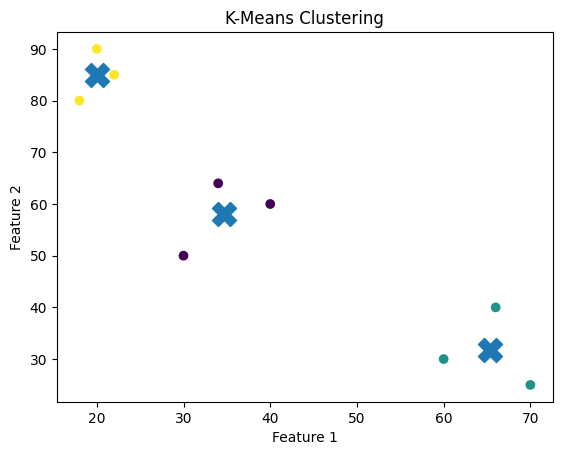

In [7]:
plt.scatter(
    X[:, 0],
    X[:, 1],
    c=labels,
    cmap='viridis'
)

# Plot the centroids on top of the data points
plt.scatter(
    kmeans.cluster_centers_[:, 0],
    kmeans.cluster_centers_[:, 1],
    s=300,
    marker='X'
)

plt.xlabel('Feature 1')  # age
plt.ylabel('Feature 2')  # expenditure
plt.title('K-Means Clustering')

plt.show()

## Key takeaways

- K-Means alternates between **assigning points to the nearest centroid** and **recomputing centroids as cluster means**, until convergence.
- Initialization matters: the naive slice-based initialization used here can converge slowly or to a suboptimal result; `k-means++` (used by scikit-learn) mitigates this by spreading out initial centroids.
- **WCSS/inertia** measures clustering quality (lower = tighter clusters) and is the metric used by the elbow method to choose `k`.
- With only 2 iterations (`max_iters=2`), the manual implementation may not fully converge — increasing `max_iters` or adding a tolerance-based stopping rule would make it more robust.